Extracting EDF parameters from ../data/Subject00_1.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 90999  =      0.000 ...   181.998 secs...
Extracting EDF parameters from ../data/Subject00_2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
<RawEDF | Subject00_1.edf, 21 x 91000 (182.0 s), ~14.6 MiB, data loaded>
<RawEDF | Subject00_2.edf, 21 x 31000 (62.0 s), ~5.0 MiB, data loaded>
Channels: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Sampling rate: 500.0
['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1']


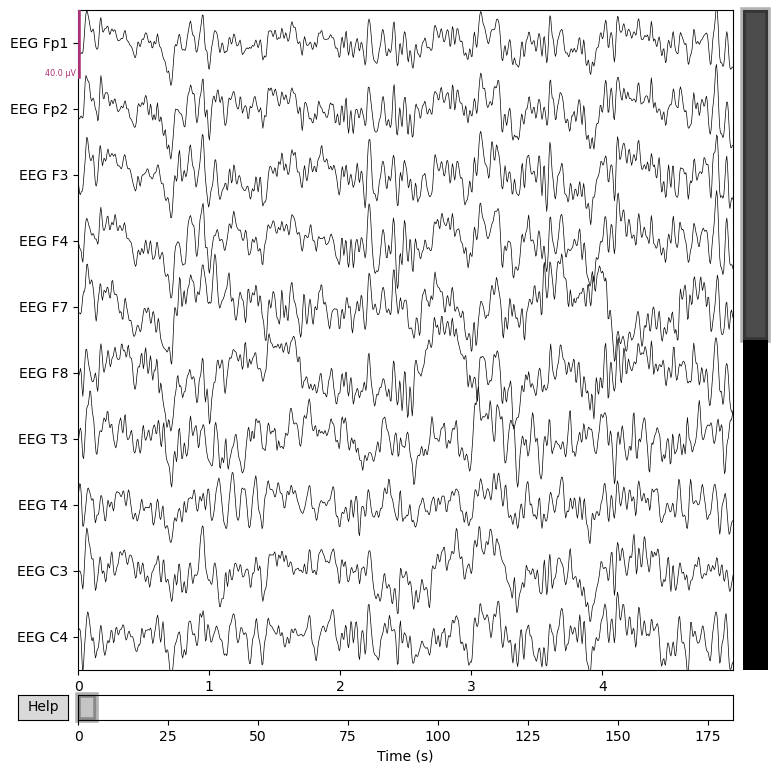

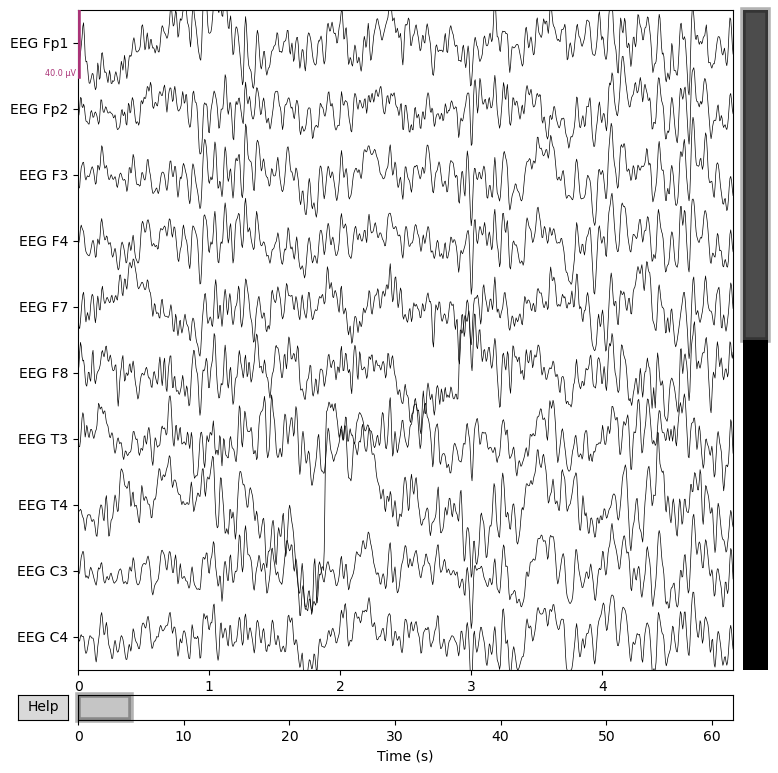

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


/var/folders/6c/g675_x4d5v5_mvns7b2x90gc0000gn/T/ipykernel_65443/1149351547.py:27: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  rest_psd.plot()
/opt/anaconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/var/folders/6c/g675_x4d5v5_mvns7b2x90gc0000gn/T/ipykernel_65443/1149351547.py:28: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  task_psd.plot()
/opt/anaconda3/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


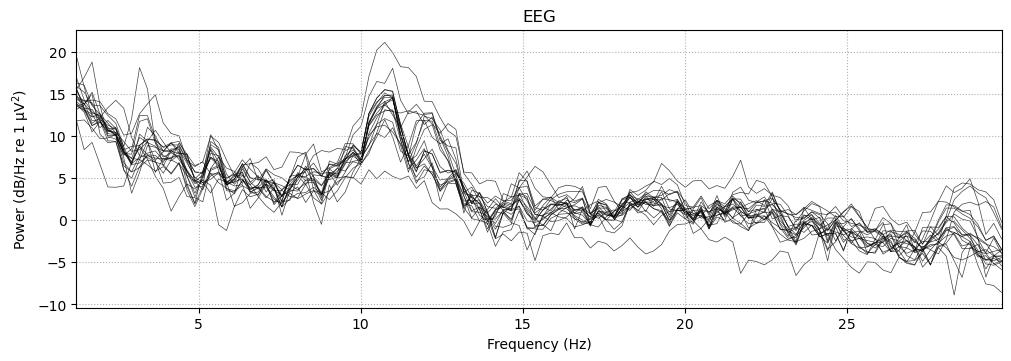

In [ ]:
import mne

# Load one baseline file
raw_rest = mne.io.read_raw_edf("../data/Subject00_1.edf", preload=True)

# Load one task file
raw_task = mne.io.read_raw_edf("../data/Subject00_2.edf", preload=True)

print(raw_rest)
print(raw_task)

print("Channels:", raw_rest.ch_names)
print("Sampling rate:", raw_rest.info["sfreq"])

# Drop non-EEG channels (specifically ECG)
drop_channels = [ch for ch in raw_rest.ch_names if "ECG" in ch]
raw_rest = raw_rest.copy().drop_channels(drop_channels)
raw_task = raw_task.copy().drop_channels(drop_channels)

print(raw_rest.ch_names)
# Quick look at a few seconds of signal
raw_rest.plot(duration=5, n_channels=10)
raw_task.plot(duration=5, n_channels=10)

rest_psd = raw_rest.compute_psd(method="welch", fmin=1, fmax=30)
task_psd = raw_task.compute_psd(method="welch", fmin=1, fmax=30)
rest_psd.plot()
task_psd.plot()

#raw information and plot of first patient data

In [3]:
import numpy as np

bands = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def get_bandpower(raw):
    psd = raw.compute_psd(method="welch", fmin=1, fmax=30)
    psds, freqs = psd.get_data(return_freqs=True)

    band_means = {}

    for band, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx].mean()  # average across channels + freq
        band_means[band] = band_power

    return band_means

rest_power = get_bandpower(raw_rest)
task_power = get_bandpower(raw_task)

print("REST:", rest_power)
print("TASK:", task_power)

#average accross all channels and frequencies in each band for rest and task, then compare

Effective window size : 4.096 (s)
Effective window size : 4.096 (s)
REST: {'theta': np.float64(3.47764225562828e-12), 'alpha': np.float64(1.2735059464620941e-11), 'beta': np.float64(1.1026802667252614e-12)}
TASK: {'theta': np.float64(3.953001151634079e-12), 'alpha': np.float64(1.0575499093307783e-11), 'beta': np.float64(1.163007268942607e-12)}


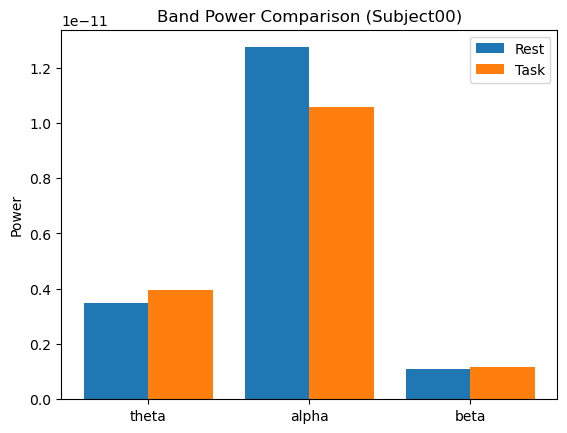

In [5]:
import matplotlib.pyplot as plt

labels = list(rest_power.keys())
rest_vals = list(rest_power.values())
task_vals = list(task_power.values())

x = np.arange(len(labels))

plt.bar(x - 0.2, rest_vals, width=0.4, label="Rest")
plt.bar(x + 0.2, task_vals, width=0.4, label="Task")

plt.xticks(x, labels)
plt.ylabel("Power")
plt.title("Band Power Comparison (Subject00)")
plt.legend()
plt.show()

In [11]:
import os
import re
import numpy as np
import pandas as pd
import mne

DATA_DIR = "../data"

bands = {
    "theta": (4, 7),
    "alpha": (8, 12),
    "beta": (13, 30),
}

def parse_filename(filename):
    """
    Extract subject ID and condition from filenames like:
    Subject00_1.edf, Subject00_2.edf
    Returns:
        subject_id (int), condition_num (int), label (int)
    label mapping:
        0 = rest/baseline (_1)
        1 = task (_2)
    """
    match = re.match(r"Subject(\d+)_(\d)\.edf$", filename)
    if not match:
        return None, None, None

    subject_id = int(match.group(1))
    condition_num = int(match.group(2))
    label = 0 if condition_num == 1 else 1
    return subject_id, condition_num, label

def load_and_clean_edf(filepath):
    """
    Load EDF and drop non-EEG channels.
    """
    raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)

    # Drop ECG if present
    drop_channels = [ch for ch in raw.ch_names if "ECG" in ch.upper()]
    if drop_channels:
        raw = raw.copy().drop_channels(drop_channels)

    return raw

def extract_bandpower_features(raw, bands):
    """
    Compute mean band power across all remaining channels.
    Returns a dict with theta/alpha/beta values.
    """
    psd = raw.compute_psd(method="welch", fmin=1, fmax=30, verbose=False)
    psds, freqs = psd.get_data(return_freqs=True)

    features = {}
    for band_name, (fmin, fmax) in bands.items():
        idx = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx].mean()
        features[band_name] = float(band_power)

    return features

rows = []

for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith(".edf"):
        continue

    subject_id, condition_num, label = parse_filename(filename)
    if subject_id is None:
        print(f"Skipping unexpected filename: {filename}")
        continue

    filepath = os.path.join(DATA_DIR, filename)

    raw = load_and_clean_edf(filepath)
    features = extract_bandpower_features(raw, bands)

    row = {
        "filename": filename,
        "subject": subject_id,
        "condition_num": condition_num,
        "condition": "rest" if label == 0 else "task",
        "label": label,
        **features,
    }
    rows.append(row)

df = pd.DataFrame(rows).sort_values(["subject", "condition_num"]).reset_index(drop=True)
print(df.shape)
print(df["condition"].value_counts())
df.head(10)


#loading in all of the patients, extracting relevant features, creating a df for analysis

(72, 8)
condition
rest    36
task    36
Name: count, dtype: int64


,filename,subject,condition_num,condition,label,theta,alpha,beta
0,Subject00_1.edf,0,1,rest,0,3.477642e-12,1.273506e-11,1.102680e-12
1,Subject00_2.edf,0,2,task,1,3.953001e-12,1.057550e-11,1.163007e-12
2,Subject01_1.edf,1,1,rest,0,3.086965e-12,3.940568e-12,9.765177e-13
3,Subject01_2.edf,1,2,task,1,5.386034e-12,3.876351e-12,8.985672e-13
4,Subject02_1.edf,2,1,rest,0,3.518997e-12,7.591754e-12,1.252376e-12
5,Subject02_2.edf,2,2,task,1,2.281701e-12,6.066956e-12,1.269864e-12
6,Subject03_1.edf,3,1,rest,0,4.132386e-12,1.365683e-11,6.583427e-13
7,Subject03_2.edf,3,2,task,1,2.508481e-12,3.749208e-12,3.311970e-13
8,Subject04_1.edf,4,1,rest,0,7.986376e-12,1.028531e-11,1.547634e-12
9,Subject04_2.edf,4,2,task,1,7.806888e-12,6.195612e-12,1.363944e-12


In [15]:
df.groupby("condition")[["theta", "alpha", "beta"]].mean()
#mean vals for each band in rest vs task conditions

,theta,alpha,beta
condition,,,
rest,3.569988e-12,8.396822e-12,6.930260e-13
task,3.494053e-12,5.482884e-12,6.028820e-13


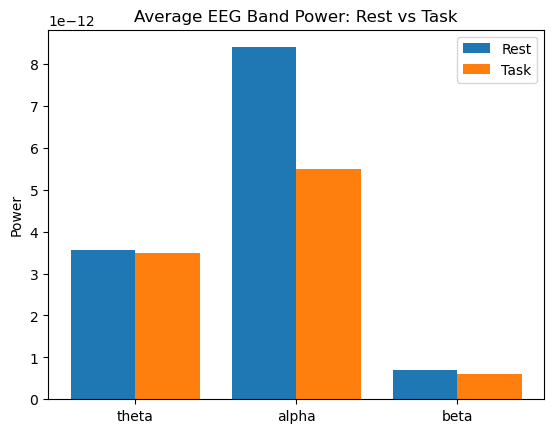

In [16]:
import matplotlib.pyplot as plt
import numpy as np

means = df.groupby("condition")[["theta", "alpha", "beta"]].mean()

labels = ["theta", "alpha", "beta"]
rest_vals = means.loc["rest"].values
task_vals = means.loc["task"].values

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, rest_vals, width=0.4, label="Rest")
plt.bar(x + 0.2, task_vals, width=0.4, label="Task")

plt.xticks(x, labels)
plt.ylabel("Power")
plt.title("Average EEG Band Power: Rest vs Task")
plt.legend()

plt.show()

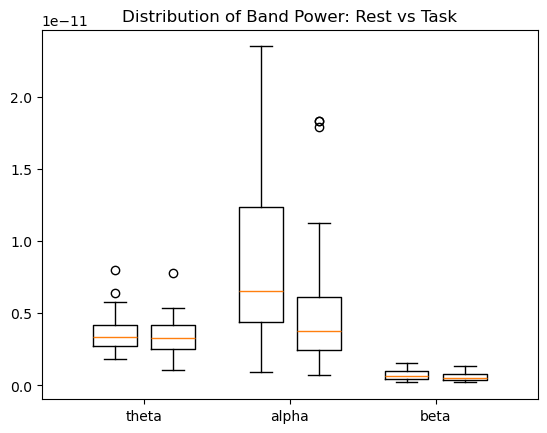

In [17]:
df_melt = df.melt(
    id_vars=["condition"],
    value_vars=["theta", "alpha", "beta"],
    var_name="band",
    value_name="power"
)

import matplotlib.pyplot as plt

plt.figure()

for i, band in enumerate(["theta", "alpha", "beta"]):
    subset = df[df["condition"] == "rest"][band]
    plt.boxplot(
        subset,
        positions=[i - 0.2],
        widths=0.3
    )

    subset = df[df["condition"] == "task"][band]
    plt.boxplot(
        subset,
        positions=[i + 0.2],
        widths=0.3
    )

plt.xticks([0, 1, 2], ["theta", "alpha", "beta"])
plt.title("Distribution of Band Power: Rest vs Task")
plt.show()

In [25]:
# separate rest and task
rest_df = df[df["condition"] == "rest"].set_index("subject")
task_df = df[df["condition"] == "task"].set_index("subject")

# align by subject
common_subjects = rest_df.index.intersection(task_df.index)

rest_df = rest_df.loc[common_subjects]
task_df = task_df.loc[common_subjects]

# compute differences
diff_df = task_df[["theta", "alpha", "beta"]] - rest_df[["theta", "alpha", "beta"]]

import numpy as np

def bootstrap_ci(data, n_boot=1000, ci=95):
    boot_means = []

    for _ in range(n_boot):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)

    return np.mean(data), lower, upper

for band in ["theta", "alpha", "beta"]:
    mean_diff, lower, upper = bootstrap_ci(diff_df[band].values)

    print(f"{band.upper()}:")
    print(f"  Mean diff = {mean_diff:.3e}")
    print(f"  95% CI = [{lower:.3e}, {upper:.3e}]\n")

#NOTE CIs do not contain 0 besides Theta, meaning alpha and beta are consistently lower in task vs rest

THETA:
  Mean diff = -7.593e-14
  95% CI = [-4.510e-13, 2.943e-13]

ALPHA:
  Mean diff = -2.914e-12
  95% CI = [-4.226e-12, -1.540e-12]

BETA:
  Mean diff = -9.014e-14
  95% CI = [-1.280e-13, -5.384e-14]

